#KNN Classification on Iris Dataset



In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(" All libraries imported successfully!")

 All libraries imported successfully!


Step 1: Load and Explore the Dataset

In [6]:
# Load the Iris dataset
iris = load_iris()
print("Dataset loaded successfully!")

# Create a DataFrame for better visualization
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].apply(lambda x: iris.target_names[x])

print("\n Dataset Overview:")
print(f"Dataset shape: {df.shape}")
print(f"Features: {iris.feature_names}")
print(f"Target classes: {list(iris.target_names)}")

# Display first few rows
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset loaded successfully!

 Dataset Overview:
Dataset shape: (150, 6)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
# Dataset Information
print(" Dataset Information:")
print(df.info())

print("\n Statistical Summary:")
df.describe()

 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

 Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# Check for missing values
print(" Missing Values Check:")
print(df.isnull().sum())

print("\n Class Distribution:")
print(df['species'].value_counts())

 Missing Values Check:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

 Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Step 2: Data Visualization

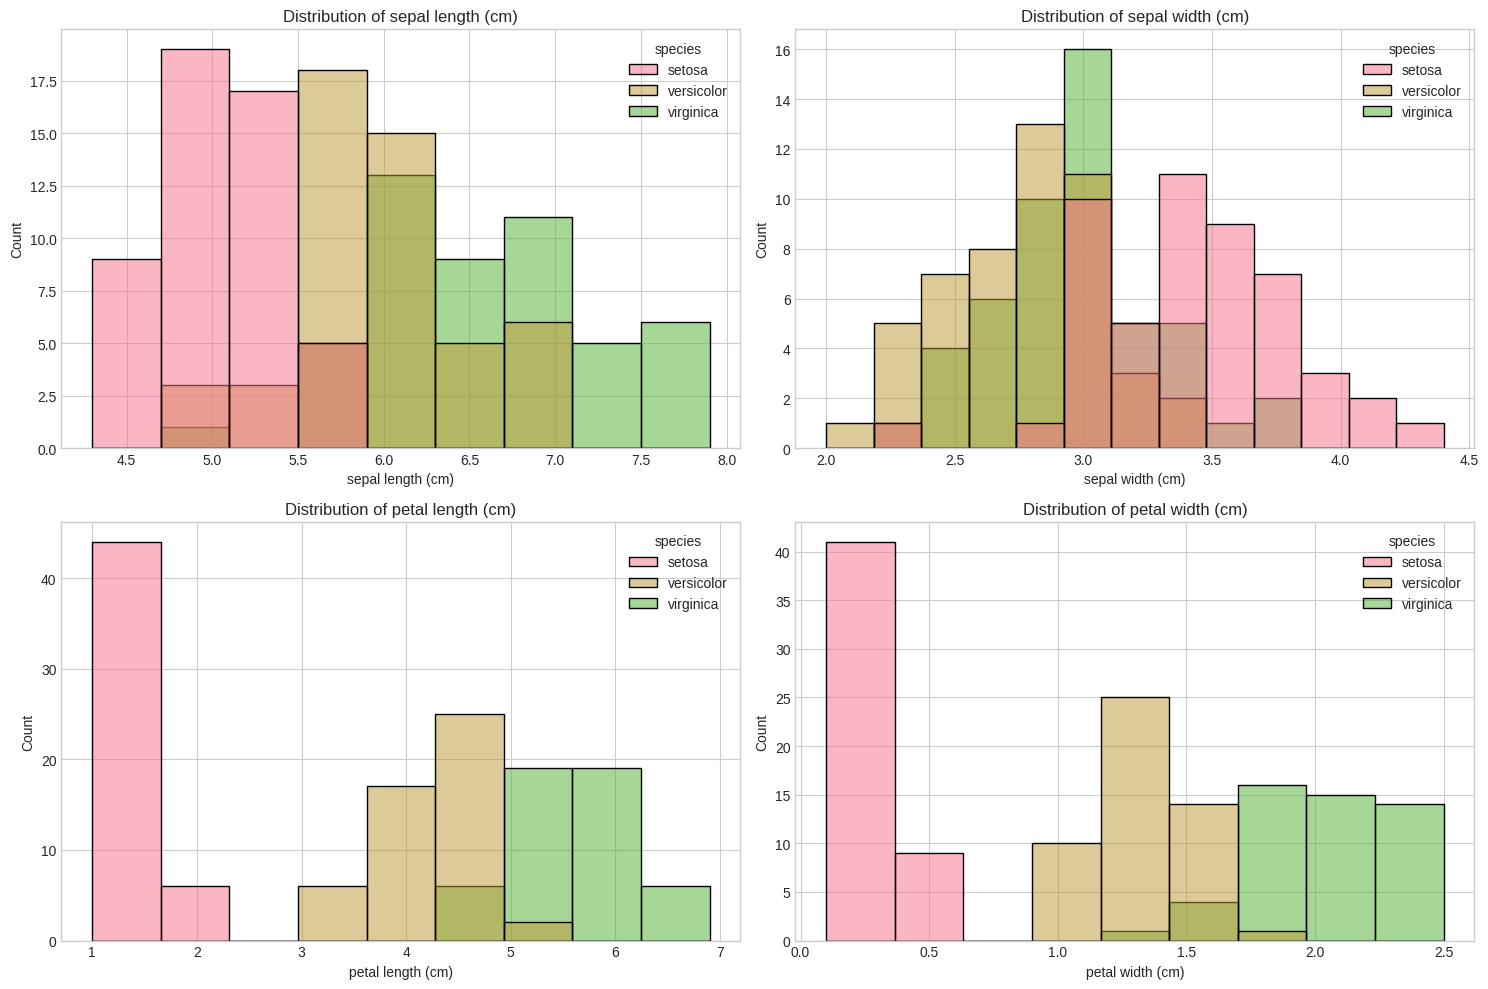

In [8]:
# Visualize the distribution of features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
features = iris.feature_names

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.histplot(data=df, x=feature, hue='species', ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

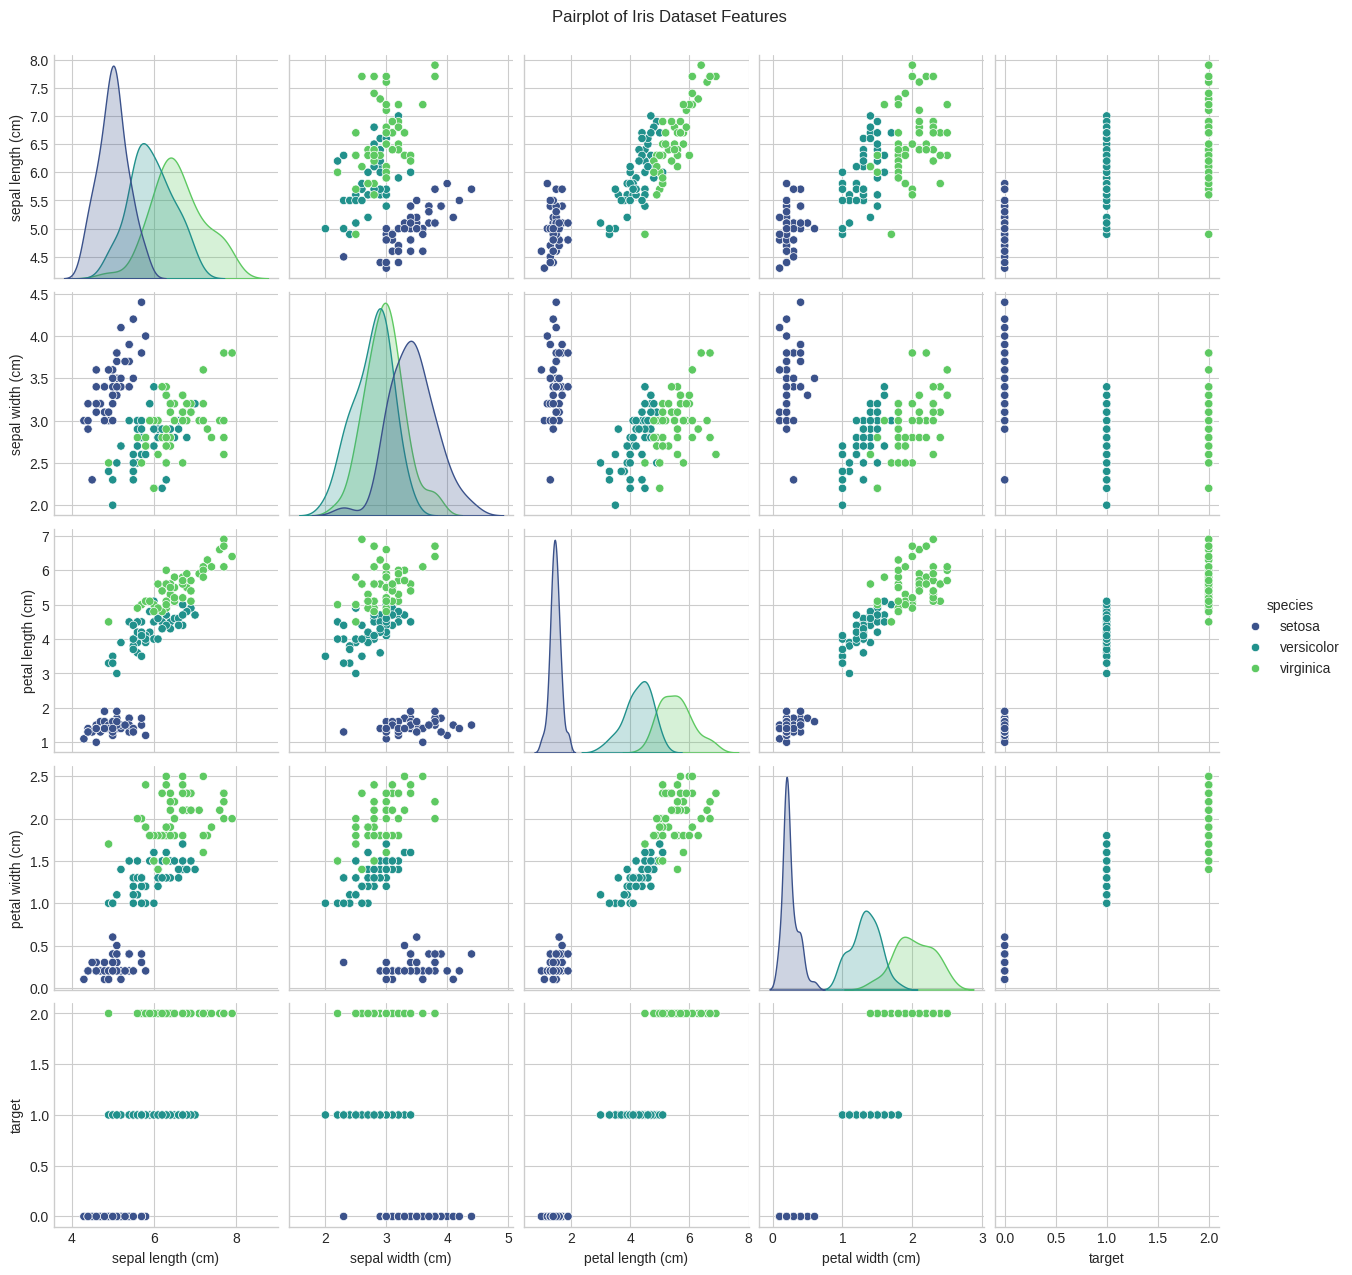

In [9]:
# Pairplot to see relationships between features
plt.figure(figsize=(12, 8))
sns.pairplot(df, hue='species', palette='viridis')
plt.suptitle('Pairplot of Iris Dataset Features', y=1.02)
plt.show()

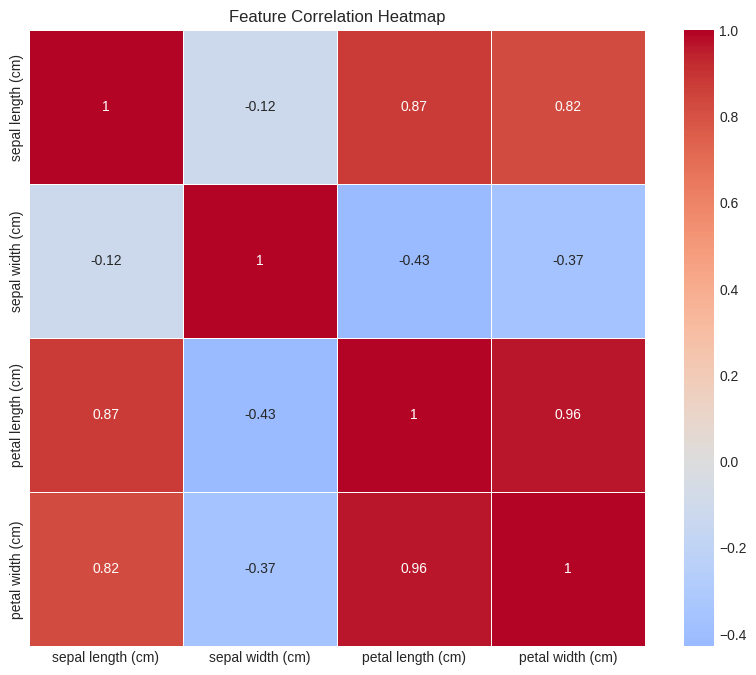

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[iris.feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

Step 3: Data Preprocessing

In [11]:
# Prepare features and target
X = df[iris.feature_names]
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n Data preprocessing completed!")

Features shape: (150, 4)
Target shape: (150,)

Training set size: 105
Testing set size: 45

 Data preprocessing completed!


Step 4: Implementing KNN from Scratch

In [14]:

import numpy as np
from collections import Counter

class KNN_From_Scratch:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):

        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        predictions = [self._predict(x) for x in np.array(X)]
        return np.array(predictions)

    def _predict(self, x):

        distances = [np.sqrt(np.sum((x - x_train)**2)) for x_train in self.X_train]


        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]


        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.sum(predictions == np.array(y)) / len(y)

print("KNN class implemented successfully!")

KNN class implemented successfully!


Step 5: Train and Evaluate KNN Models

In [16]:
knn_custom = KNN_From_Scratch(k=5)
knn_custom.fit(X_train_scaled, y_train)


y_test_np = np.array(y_test)
y_pred_custom = knn_custom.predict(X_test_scaled)


custom_accuracy = knn_custom.accuracy(X_test_scaled, y_test)
print(f" Custom KNN Model Accuracy: {custom_accuracy:.4f}")


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_sklearn = KNeighborsClassifier(n_neighbors=5)
knn_sklearn.fit(X_train_scaled, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test_scaled)
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)

print(f" Scikit-learn KNN Model Accuracy: {sklearn_accuracy:.4f}")


print(f"\n Accuracy Difference: {abs(custom_accuracy - sklearn_accuracy):.4f}")

 Custom KNN Model Accuracy: 0.9111
 Scikit-learn KNN Model Accuracy: 0.9111

 Accuracy Difference: 0.0000


Step 6: Finding the Optimal K Value

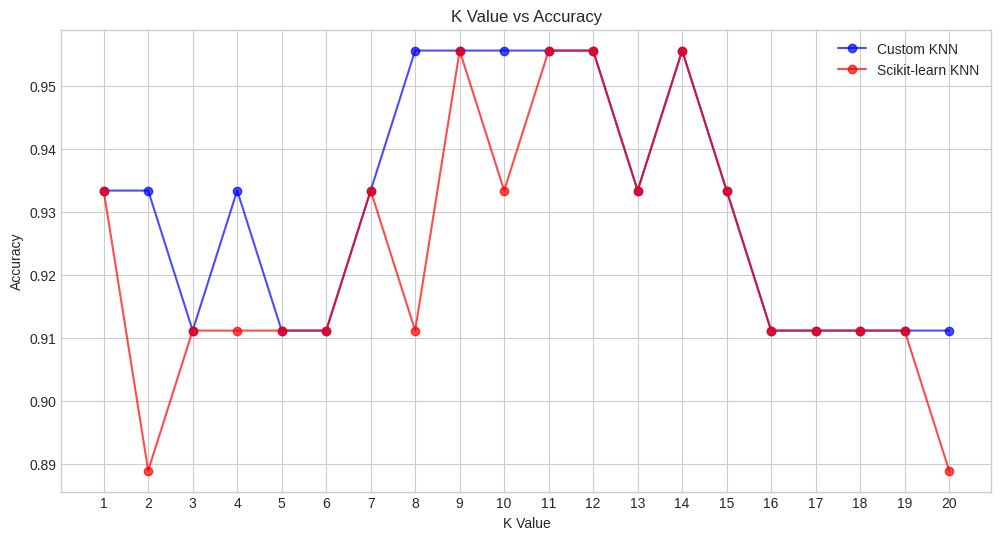

 Best K for Custom KNN: 8 (Accuracy: 0.9556)
 Best K for Scikit-learn KNN: 9 (Accuracy: 0.9556)


In [17]:
# Find the best k value
k_values = range(1, 21)
custom_accuracies = []
sklearn_accuracies = []

for k in k_values:
    # Custom KNN
    knn_temp = KNN_From_Scratch(k=k)
    knn_temp.fit(X_train_scaled, y_train)
    custom_acc = knn_temp.accuracy(X_test_scaled, y_test)
    custom_accuracies.append(custom_acc)

    # Sklearn KNN
    knn_sk_temp = KNeighborsClassifier(n_neighbors=k)
    knn_sk_temp.fit(X_train_scaled, y_train)
    sk_acc = knn_sk_temp.score(X_test_scaled, y_test)
    sklearn_accuracies.append(sk_acc)

# Plot accuracy vs k values
plt.figure(figsize=(12, 6))
plt.plot(k_values, custom_accuracies, 'bo-', label='Custom KNN', alpha=0.7)
plt.plot(k_values, sklearn_accuracies, 'ro-', label='Scikit-learn KNN', alpha=0.7)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('K Value vs Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

# Find best k
best_k_custom = k_values[np.argmax(custom_accuracies)]
best_k_sklearn = k_values[np.argmax(sklearn_accuracies)]

print(f" Best K for Custom KNN: {best_k_custom} (Accuracy: {max(custom_accuracies):.4f})")
print(f" Best K for Scikit-learn KNN: {best_k_sklearn} (Accuracy: {max(sklearn_accuracies):.4f})")

Step 7: Model Evaluation with Best K

In [20]:
# Train final model with best k
final_knn = KNeighborsClassifier(n_neighbors=best_k_sklearn)
final_knn.fit(X_train_scaled, y_train)
y_pred_final = final_knn.predict(X_test_scaled)
final_accuracy = accuracy_score